In [3]:
import os, random, shutil, zipfile, glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE
print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [4]:

URL = "https://raw.githubusercontent.com/Digital-Media/cv_data/main/binary_leaves.zip"
ZIP = "binary_leaves.zip"

!rm -rf binary_leaves binary_leaves.zip data_split
!curl -L -o "$ZIP" "$URL" --silent

with zipfile.ZipFile(ZIP, "r") as z:
    z.extractall(".")

print("Extracted folders:", [p for p in os.listdir(".") if os.path.isdir(p)][:10])


Extracted folders: ['.config', 'binary_leaves', 'sample_data']


In [5]:

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def is_image_file(fn: str) -> bool:
    return fn.lower().endswith(IMG_EXTS)

def find_dataset_root(start_dir="."):
    for root, dirs, files in os.walk(start_dir):
        if root.count(os.sep) > 4:
            continue
        if len(dirs) < 2:
            continue
        # check a few subdirs for images
        ok = 0
        for d in dirs[:20]:
            p = os.path.join(root, d)
            if not os.path.isdir(p):
                continue
            imgs = [f for f in os.listdir(p) if is_image_file(f)]
            if len(imgs) > 0:
                ok += 1
        if ok >= 2:
            return root
    return None

DATA_DIR = find_dataset_root(".")
print("Detected DATA_DIR:", DATA_DIR)
assert DATA_DIR is not None, "Dataset root not found. Check unzip contents."


Detected DATA_DIR: ./binary_leaves


In [6]:

classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print("Classes:", classes)

counts = {}
total = 0
for c in classes:
    p = os.path.join(DATA_DIR, c)
    imgs = [f for f in os.listdir(p) if is_image_file(f)]
    counts[c] = len(imgs)
    total += len(imgs)

print("Total images:", total)
for c in classes:
    print(f"{c:30s} {counts[c]}")


Classes: ['0', '1', '2', '3', '4']
Total images: 282
0                              56
1                              55
2                              62
3                              53
4                              56


In [7]:
OUT = "data_split"
TRAIN_DIR = os.path.join(OUT, "train")
VAL_DIR = os.path.join(OUT, "val")

VAL_RATIO = 0.2  # small dataset: keep some for validation

def safe_mkdir(p):
    os.makedirs(p, exist_ok=True)

# rebuild split folders
if os.path.exists(OUT):
    shutil.rmtree(OUT)
safe_mkdir(TRAIN_DIR)
safe_mkdir(VAL_DIR)

for c in classes:
    src = os.path.join(DATA_DIR, c)
    imgs = [os.path.join(src, f) for f in os.listdir(src) if is_image_file(f)]
    imgs = sorted(imgs)
    random.shuffle(imgs)

    n_val = max(1, int(len(imgs) * VAL_RATIO))
    val_imgs = imgs[:n_val]
    train_imgs = imgs[n_val:]

    safe_mkdir(os.path.join(TRAIN_DIR, c))
    safe_mkdir(os.path.join(VAL_DIR, c))

    for fp in train_imgs:
        shutil.copy2(fp, os.path.join(TRAIN_DIR, c, os.path.basename(fp)))
    for fp in val_imgs:
        shutil.copy2(fp, os.path.join(VAL_DIR, c, os.path.basename(fp)))

print("Split created at:", OUT)


Split created at: data_split


In [8]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    color_mode="rgb",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    color_mode="rgb",
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("class_names:", class_names)
print("num_classes:", num_classes)

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


Found 227 files belonging to 5 classes.
Found 55 files belonging to 5 classes.
class_names: ['0', '1', '2', '3', '4']
num_classes: 5


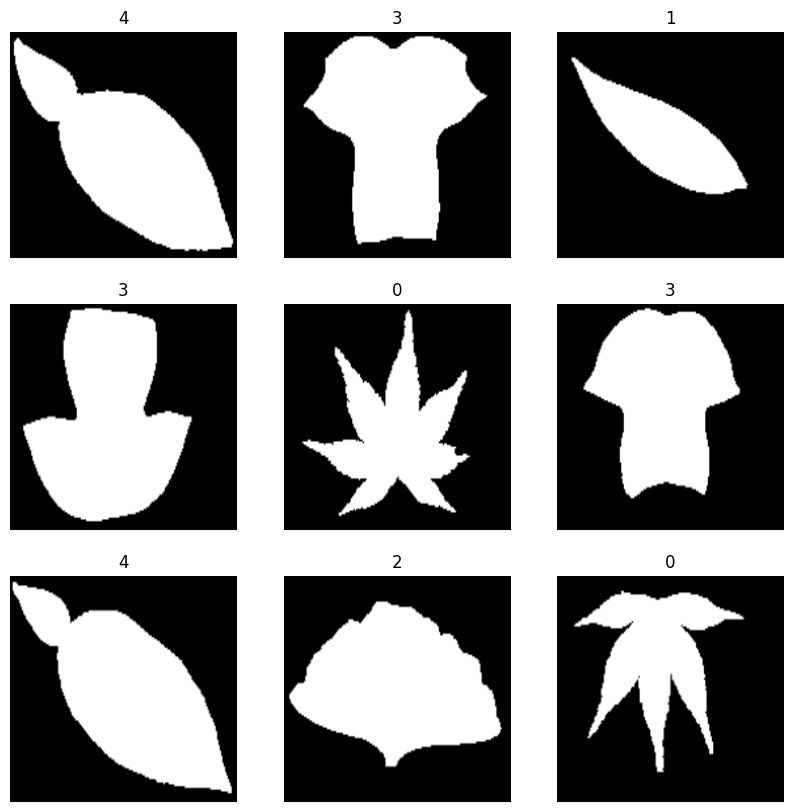

In [9]:

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.show()


In [10]:

from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.1),
    ],
    name="augmentation",
)

base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base.trainable = False

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_leaf_model.keras", monitor="val_accuracy", save_best_only=True),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

EPOCHS_1 = 12
history1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_1, callbacks=callbacks)


Epoch 1/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.3436 - loss: 1.6207 - val_accuracy: 0.7455 - val_loss: 0.8488 - learning_rate: 0.0010
Epoch 2/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6314 - loss: 0.8799 - val_accuracy: 0.7818 - val_loss: 0.4616 - learning_rate: 0.0010
Epoch 3/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8366 - loss: 0.4581 - val_accuracy: 0.8727 - val_loss: 0.2841 - learning_rate: 0.0010
Epoch 4/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9525 - loss: 0.2296 - val_accuracy: 0.9091 - val_loss: 0.2340 - learning_rate: 0.0010
Epoch 5/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9378 - loss: 0.2020 - val_accuracy: 0.9818 - val_loss: 0.1796 - learning_rate: 0.0010
Epoch 6/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9549 - loss: 0.1625 - val_accuracy: 1.0000 - val_loss: 0.1211 - learning_rate: 0.0010
Epoch 7/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9625 - loss: 0.1435 - val_accuracy: 1.0000 - val_l

In [12]:
base.trainable = True

for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

N = 40  # unfreeze only last N layers
for layer in base.layers[:-N]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

EPOCHS_2 = 6
history2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_2, callbacks=callbacks)


Epoch 1/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9761 - loss: 0.1233 - val_accuracy: 0.9636 - val_loss: 0.1397 - learning_rate: 1.0000e-05
Epoch 2/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9593 - loss: 0.1137 - val_accuracy: 1.0000 - val_loss: 0.0364 - learning_rate: 1.0000e-05
Epoch 3/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9802 - loss: 0.0603 - val_accuracy: 1.0000 - val_loss: 0.0350 - learning_rate: 1.0000e-05
Epoch 4/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9855 - loss: 0.0338 - val_accuracy: 1.0000 - val_loss: 0.0359 - learning_rate: 1.0000e-05
Epoch 5/6
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9909 - loss: 0.0517 - val_accuracy: 1.0000 - val_loss: 0.0542 - learning_rate: 1.0000e-05


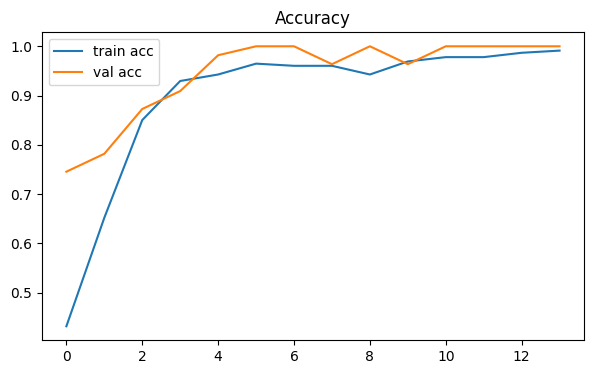

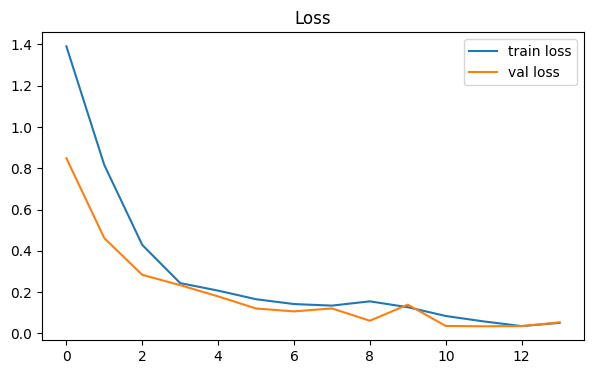

In [13]:
def join_hist(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

acc = join_hist(history1, history2, "accuracy")
val_acc = join_hist(history1, history2, "val_accuracy")
loss = join_hist(history1, history2, "loss")
val_loss = join_hist(history1, history2, "val_loss")

plt.figure(figsize=(7, 4))
plt.plot(acc, label="train acc")
plt.plot(val_acc, label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(loss, label="train loss")
plt.plot(val_loss, label="val loss")
plt.legend()
plt.title("Loss")
plt.show()


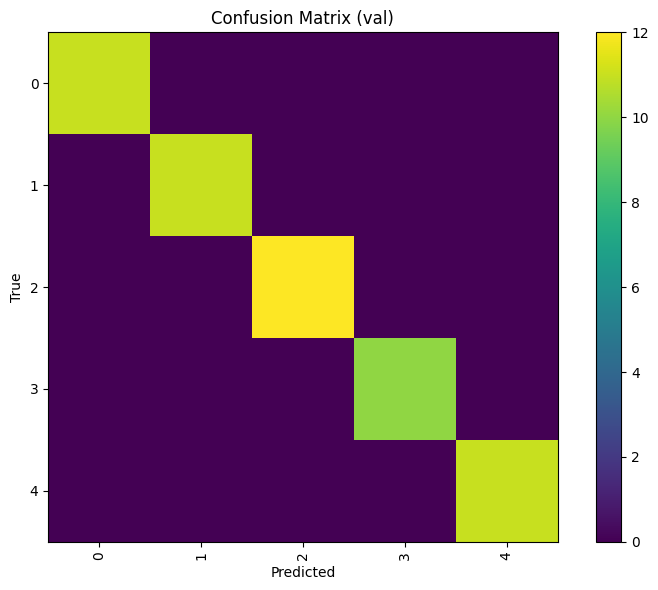

0                         acc=1.000  (n=11)
1                         acc=1.000  (n=11)
2                         acc=1.000  (n=12)
3                         acc=1.000  (n=10)
4                         acc=1.000  (n=11)


In [14]:
y_true, y_pred = [], []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix (val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
for i, name in enumerate(class_names):
    print(f"{name:25s} acc={per_class_acc[i]:.3f}  (n={cm.sum(axis=1)[i]})")


In [15]:
model.save("leaf_model_final.keras")
best_model = tf.keras.models.load_model("best_leaf_model.keras")
print("Saved leaf_model_final.keras and loaded best_leaf_model.keras")


Saved leaf_model_final.keras and loaded best_leaf_model.keras


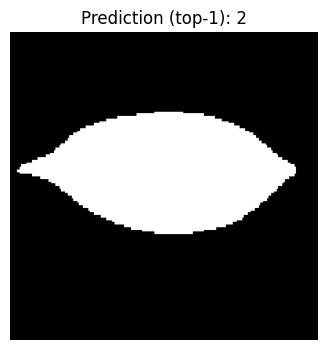

2: 0.3830
3: 0.2766
4: 0.1588


In [16]:

# pick one file from val set
all_val_imgs = []
for c in class_names:
    all_val_imgs += glob.glob(os.path.join(VAL_DIR, c, "*"))
img_path = random.choice(all_val_imgs)

img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
x = tf.keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

probs = best_model.predict(x, verbose=0)[0]
top = probs.argsort()[-3:][::-1]

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Prediction (top-1): " + class_names[int(top[0])])
plt.show()

for idx in top:
    print(f"{class_names[int(idx)]}: {probs[int(idx)]:.4f}")


In [17]:
with open("class_names.txt", "w", encoding="utf-8") as f:
    for c in class_names:
        f.write(c + "\n")
print("Wrote class_names.txt")


Wrote class_names.txt
